In [1]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
# ============================================================
# Load Clean Dataset
# ============================================================

df = pd.read_csv("../data/processed/clean_telco_churn.csv")

print(df.shape)

df.head()

(7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ============================================================
# Remove Identifier
# ============================================================

df = df.drop(columns=["customerID"])

print(df.shape)

(7032, 20)


In [6]:
# ============================================================
# Features and Target
# ============================================================

X = df.drop(columns=["Churn"])

y = df["Churn"]

print("Features :", X.shape)
print("Target :", y.shape)

Features : (7032, 19)
Target : (7032,)


In [7]:
# ============================================================
# Encode Target Variable
# ============================================================

y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [8]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (5625, 19)
Testing Set : (1407, 19)


In [10]:
# ============================================================
# Numerical and Categorical Columns
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
# ============================================================
# Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )

    ]

)

# Model 1 - Logistic Regression

In [12]:
# ============================================================
# Logistic Regression Pipeline
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [13]:
# ============================================================
# Predictions
# ============================================================

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [14]:
# ============================================================
# Model Evaluation
# ============================================================

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1 Score : 0.608
ROC AUC  : 0.8359


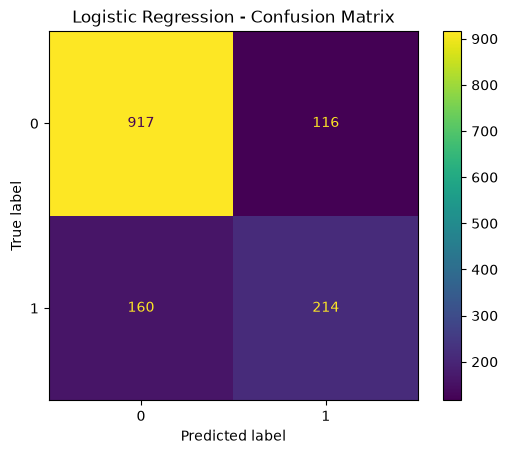

In [15]:
# ============================================================
# Confusion Matrix
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [16]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob)]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.608,0.8359


# 🌳 Model 2 - Decision Tree

In [17]:
# ============================================================
# Decision Tree Pipeline
# ============================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [18]:
# ============================================================
# Decision Tree Predictions
# ============================================================

dt_pred = decision_tree.predict(X_test)
dt_prob = decision_tree.predict_proba(X_test)[:, 1]

In [19]:
# ============================================================
# Decision Tree Performance
# ============================================================

print("Accuracy :", round(accuracy_score(y_test, dt_pred), 4))
print("Precision:", round(precision_score(y_test, dt_pred), 4))
print("Recall   :", round(recall_score(y_test, dt_pred), 4))
print("F1 Score :", round(f1_score(y_test, dt_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, dt_prob), 4))

Accuracy : 0.7896
Precision: 0.6021
Recall   : 0.615
F1 Score : 0.6085
ROC AUC  : 0.8296


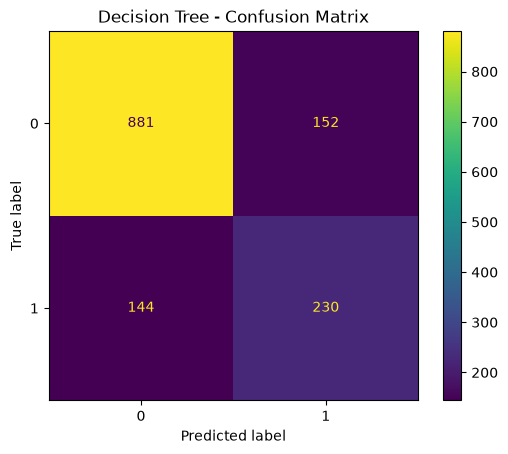

In [20]:
# ============================================================
# Decision Tree Confusion Matrix
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [21]:
results.loc[len(results)] = [
    "Decision Tree",
    round(accuracy_score(y_test, dt_pred), 4),
    round(precision_score(y_test, dt_pred), 4),
    round(recall_score(y_test, dt_pred), 4),
    round(f1_score(y_test, dt_pred), 4),
    round(roc_auc_score(y_test, dt_prob), 4)
]

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,Decision Tree,0.7896,0.6021,0.6150,0.6085,0.8296


# 🌳 Model 3 - Random Forest

In [22]:
# ============================================================
# Random Forest Pipeline
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [23]:
rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

In [24]:
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, rf_prob), 4))

Accuracy : 0.7896
Precision: 0.6345
Recall   : 0.492
F1 Score : 0.5542
ROC AUC  : 0.814


In [25]:
results.loc[len(results)] = [
    "Random Forest",
    round(accuracy_score(y_test, rf_pred), 4),
    round(precision_score(y_test, rf_pred), 4),
    round(recall_score(y_test, rf_pred), 4),
    round(f1_score(y_test, rf_pred), 4),
    round(roc_auc_score(y_test, rf_prob), 4)
]

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,Decision Tree,0.7896,0.6021,0.6150,0.6085,0.8296
2,Random Forest,0.7896,0.6345,0.4920,0.5542,0.8140


In [26]:
# ============================================================
# Get Feature Names after One-Hot Encoding
# ============================================================

feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

len(feature_names)

45

In [27]:
# ============================================================
# Logistic Regression Coefficients
# ============================================================

coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    "Absolute",
    ascending=False
)

importance.head(15)

,Feature,Coefficient,Absolute
1,num__tenure,-1.352313,1.352313
38,cat__Contract_Two year,-0.779030,0.779030
3,num__TotalCharges,0.644014,0.644014
15,cat__InternetService_DSL,-0.616132,0.616132
36,cat__Contract_Month-to-month,0.613846,0.613846
16,cat__InternetService_Fiber optic,0.590184,0.590184
2,num__MonthlyCharges,-0.541006,0.541006
39,cat__PaperlessBilling_No,-0.300387,0.300387
12,cat__MultipleLines_No,-0.293470,0.293470
17,cat__InternetService_No,-0.283724,0.283724


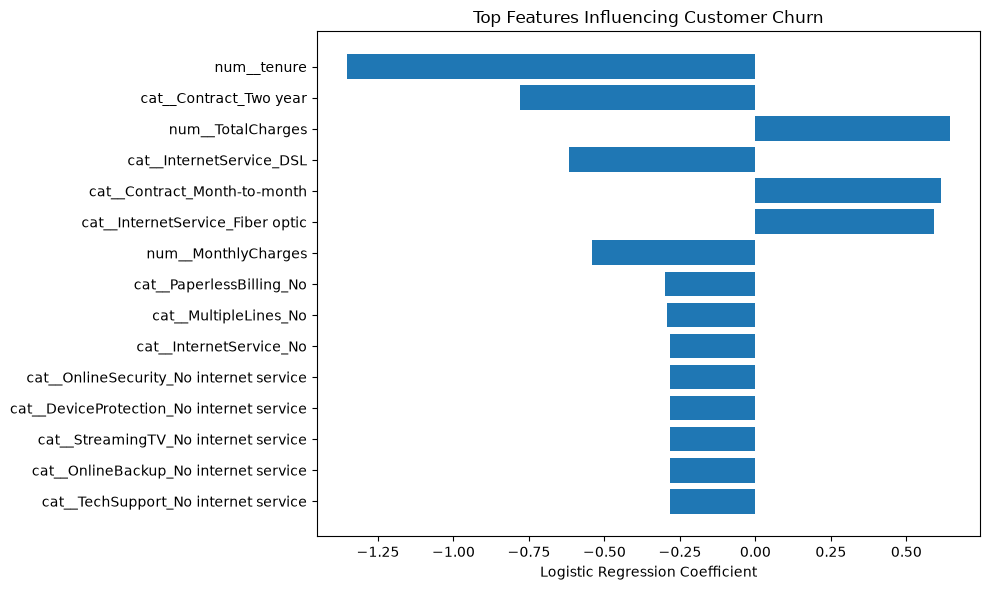

In [28]:
# ============================================================
# Top 15 Most Important Features
# ============================================================

top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()